Polynomial Features

Polynomial degree: 1
Training MSE: 42.90
Polynomial degree: 2
Training MSE: 20.44
Polynomial degree: 10
Training MSE: 18.26


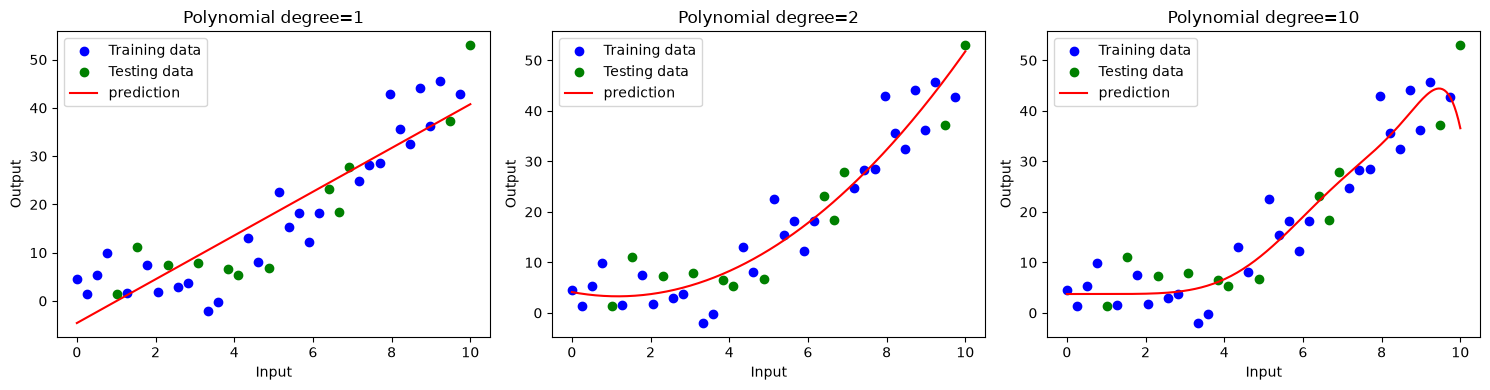

Testing MSE: 38.42



In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#generate reproducable nonlinear data
np.random.seed(42)

X=np.linspace(0,10,40).reshape(-1,1)

#np.random.normal(0,5,40) is to generate random noise
#this adds the reliastic variation to the output data
#np.random.normal(mean,std,no_of_values)
y=2+0.5*X[:,0]**2+np.random.normal(0,5,40)#y=2+0.5x**2 is the poly fn

#Divide the data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,10]
#include_bias=False is to tell Poly...features not to create an additional constant col containing only 1s
for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)

    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse=mean_squared_error(y_train,train_prediction)
    test_mse=mean_squared_error(y_test,test_prediction)

    print(f"Polynomial degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    X_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))

for index,degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="prediction")

    plt.title(f"Polynomial degree={degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
plt.tight_layout()
plt.show()
print(f"Testing MSE: {test_mse:.2f}")
print()

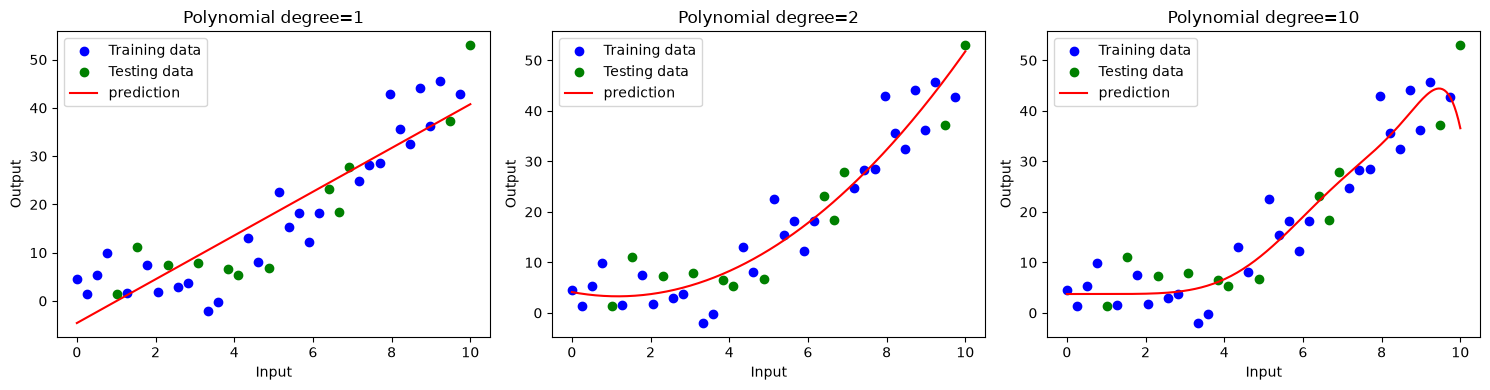

In [4]:
X_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))

for index,degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="prediction")

    plt.title(f"Polynomial degree={degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()
plt.tight_layout()
plt.show()

Cross-Validation and model Selection

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#generate reproducable nonlinear data
np.random.seed(42)

X=np.linspace(0,500,1000).reshape(-1,1)

#np.random.normal(0,5,40) is to generate random noise
#this adds the reliastic variation to the output data
#np.random.normal(mean,std,no_of_values)
y=2+0.5*X[:,0]**2+np.random.normal(0,5,1000)#y=2+0.5x**2 is the poly fn

#Divide the data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,3,4,5,10]
#include_bias=False is to tell Poly...features not to create an additional constant col containing only 1s
for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)

    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse=mean_squared_error(y_train,train_prediction)
    test_mse=mean_squared_error(y_test,test_prediction)

    print(f"Polynomial degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    print(f"Testing MSE: {test_mse:.2f}")
    print()

Polynomial degree: 1
Training MSE: 84979212.68
Testing MSE: 92341640.59

Polynomial degree: 2
Training MSE: 23.77
Testing MSE: 24.40

Polynomial degree: 3
Training MSE: 23.73
Testing MSE: 24.48

Polynomial degree: 4
Training MSE: 3144349.09
Testing MSE: 3198677.70

Polynomial degree: 5
Training MSE: 15983924.67
Testing MSE: 16015230.99

Polynomial degree: 10
Training MSE: 178276554.56
Testing MSE: 182729826.73



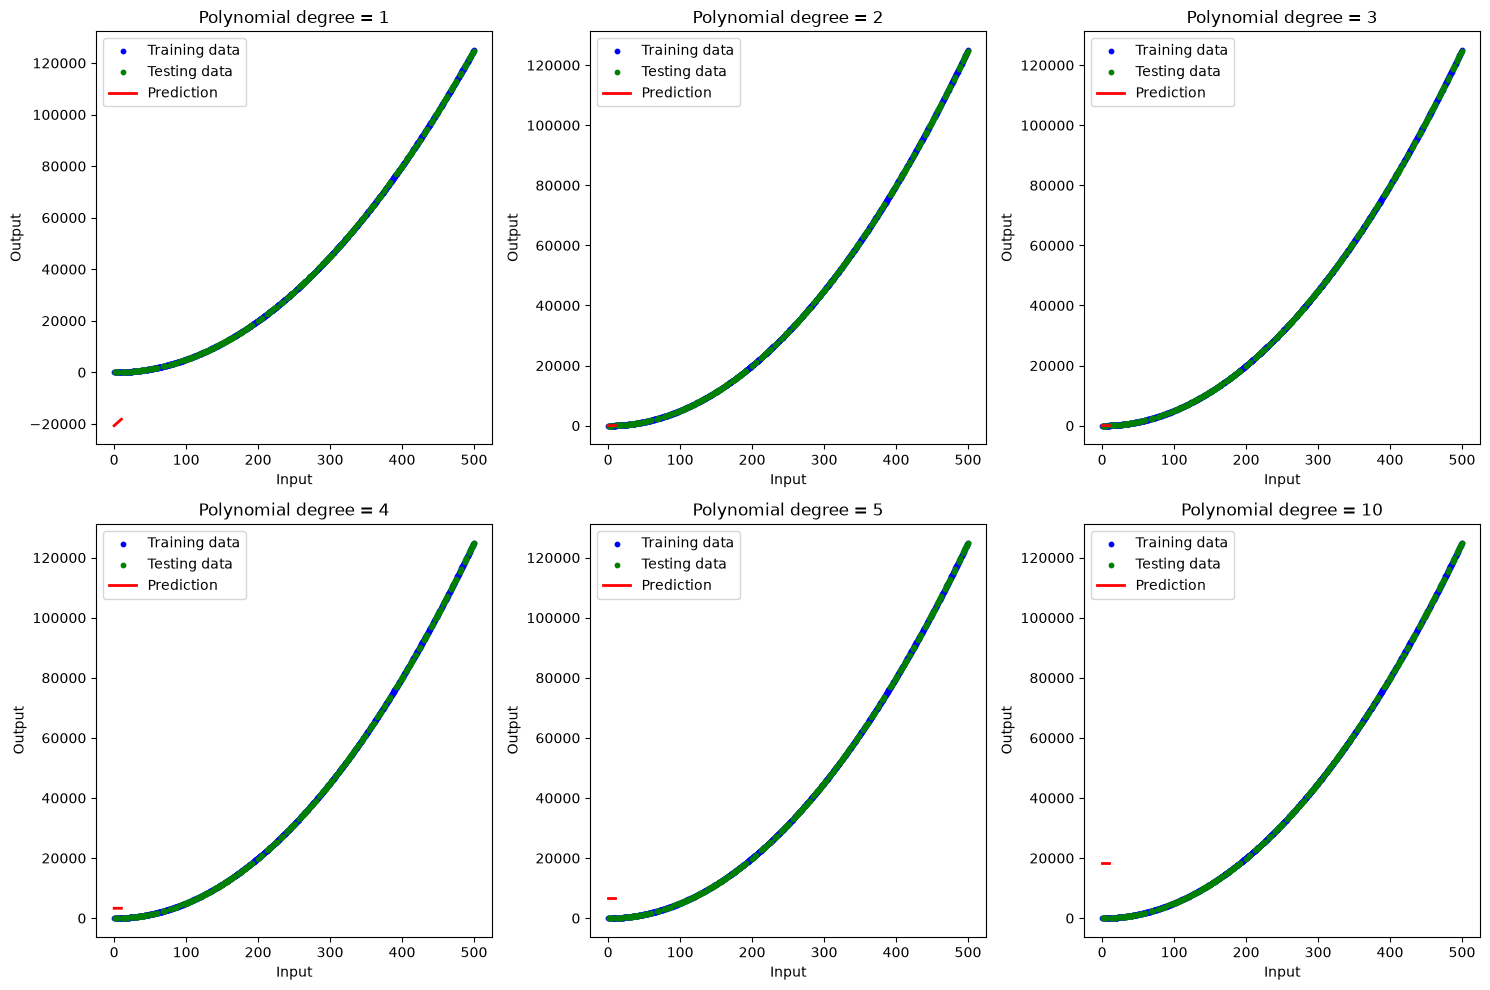

In [13]:
plt.figure(figsize=(15, 10))

for index, degree in enumerate(degrees):

    model = make_pipeline(
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_plot = model.predict(X_plot)

    plt.subplot(2, 3, index + 1)

    plt.scatter(
        X_train,
        y_train,
        color="blue",
        s=10,
        label="Training data"
    )

    plt.scatter(
        X_test,
        y_test,
        color="green",
        s=10,
        label="Testing data"
    )

    plt.plot(
        X_plot,
        y_plot,
        color="red",
        linewidth=2,
        label="Prediction"
    )

    plt.title(f"Polynomial degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Generate reproducible nonlinear data
np.random.seed(42)
X = np.linspace(0, 500, 1000).reshape(-1, 1)
y = 2 + 0.5 * X[:, 0] ** 2 + np.random.normal(0, 5, 1000)

# Define configurations to test
test_sizes = [ 0.20, 0.25, 0.30]
degrees = [1,2,3,4,5,10]  # Comparing a good fit (1) and a high-complexity model (10)
results = []

for test_size in test_sizes:
  for degree in degrees:
    # Divide the data with the current test_size
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )

    model.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    results.append({
        "Test Size": f"{int(test_size * 100)}%",
        "Degree": degree,
        "Train MSE": round(train_mse, 2),
        "Test MSE": round(test_mse, 2),
    })

# Convert to DataFrame and print as a Markdown table
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

# Find the row with the minimum Test MSE
best_row = df_results.loc[df_results["Test MSE"].idxmin()]

print("--- Best Performing Model ---")
print(best_row)

| Test Size   |   Degree |    Train MSE |     Test MSE |
|:------------|---------:|-------------:|-------------:|
| 20%         |        1 |  8.74494e+07 |  8.61322e+07 |
| 20%         |        2 | 23.95        | 23.8         |
| 20%         |        3 | 23.93        | 23.85        |
| 20%         |        4 |  3.19717e+06 |  3.01542e+06 |
| 20%         |        5 |  1.61836e+07 |  1.52354e+07 |
| 20%         |       10 |  1.77804e+08 |  1.8625e+08  |
| 25%         |        1 |  8.58241e+07 |  9.12044e+07 |
| 25%         |        2 | 23.75        | 24.52        |
| 25%         |        3 | 23.72        | 24.55        |
| 25%         |        4 |  3.16486e+06 |  3.14872e+06 |
| 25%         |        5 |  1.60322e+07 |  1.58843e+07 |
| 25%         |       10 |  1.76551e+08 |  1.88579e+08 |
| 30%         |        1 |  8.49792e+07 |  9.23416e+07 |
| 30%         |        2 | 23.77        | 24.4         |
| 30%         |        3 | 23.73        | 24.48        |
| 30%         |        4 |  3.1